## Task 3: Develop machine learning pipelines for preprocessing, training, and evaluation of predictive models
*Dataset Utilized: Pima Indians Diabetes Dataset (Bundling Imputation, Scaling, and SVC Model)*


### Subtask 3.1: Constructing the End-to-End Machine Learning Pipeline
**Concept:** Construct a pipeline that bundles missing value imputation (replacing invalid zeros with median values) and standard scaling together with a Support Vector Classifier (SVC).


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Pima Indians Diabetes Dataset
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Dataset column names
pima_cols = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

print("Task 3 setup completed successfully.")

Task 3 setup completed successfully.


In [2]:
import warnings

In [3]:
warnings.filterwarnings("ignore")

In [4]:
import pandas as pd

In [5]:
import numpy as np

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
from sklearn.pipeline import Pipeline

In [8]:
from sklearn.impute import SimpleImputer

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
from sklearn.svm import SVC

In [11]:
pima_raw_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [12]:
X_raw_p = pima_raw_df[pima_cols[:-1]].copy()

In [13]:
y_raw_p = pima_raw_df['Outcome']

In [14]:
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [15]:
X_raw_p[cols_to_impute] = X_raw_p[cols_to_impute].replace(0, np.nan)

In [16]:
X_train_raw_p, X_test_raw_p, y_train_raw_p, y_test_raw_p = train_test_split(
    X_raw_p, y_raw_p, test_size=0.20, stratify=y_raw_p, random_state=42
)

In [17]:
ml_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()),                 
    ('classifier', SVC(probability=True, class_weight='balanced', random_state=42)) 
])

In [18]:
print("Cost-sensitive balanced Pipeline constructed successfully.")

Cost-sensitive balanced Pipeline constructed successfully.


### Subtask 3.2: Tuning the Pipeline with Grid Search
**Concept:** Configure a GridSearchCV parameter grid using double-underscore syntax to tune imputation, scaling, and classification parameters simultaneously while preventing data leakage.


In [19]:
from sklearn.model_selection import GridSearchCV

In [20]:
pipeline_param_grid = {
    'imputer__strategy': ['mean', 'median'],          
    'classifier__C': [0.1, 1, 5, 10, 50],               
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1] 
}

In [21]:
pipeline_cv = GridSearchCV(estimator=ml_pipeline, param_grid=pipeline_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

In [22]:
pipeline_cv.fit(X_train_raw_p, y_train_raw_p)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1, ...], 'classifier__gamma': ['scale', 'auto', ...], 'imputer__strategy': ['mean', 'median']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

In [23]:
best_pipeline = pipeline_cv.best_estimator_

In [24]:
print("Optimal Pipeline Hyperparameters Selected:")
print(pipeline_cv.best_params_)

Optimal Pipeline Hyperparameters Selected:
{'classifier__C': 1, 'classifier__gamma': 0.01, 'imputer__strategy': 'median'}


### Subtask 3.3: Evaluating the Tuned Pipeline on Raw Test Data
**Concept:** Predict on the raw, unprocessed test data using the tuned pipeline, and evaluate its performance using accuracy, a confusion matrix, and a classification report.


In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [26]:
import seaborn as sns

In [27]:
import matplotlib.pyplot as plt

In [28]:
pipeline_preds = best_pipeline.predict(X_test_raw_p)

In [29]:
pipeline_accuracy = accuracy_score(y_test_raw_p, pipeline_preds)

In [30]:
print(f"End-to-End Pipeline Test Accuracy: {pipeline_accuracy * 100:.2f}%\\n")

End-to-End Pipeline Test Accuracy: 74.03%\n


In [31]:
print("--- Classification Report (Observe the improved Class 1 metrics) ---")
print(classification_report(y_test_raw_p, pipeline_preds))

--- Classification Report (Observe the improved Class 1 metrics) ---
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       100
           1       0.61      0.72      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.75      0.74      0.74       154



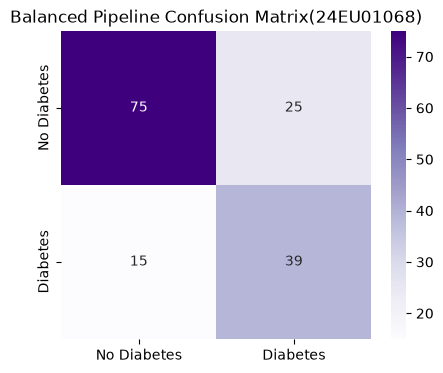

In [43]:
cm_pipeline = confusion_matrix(y_test_raw_p, pipeline_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pipeline, annot=True, fmt='d', cmap='Purples', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title("Balanced Pipeline Confusion Matrix(24EU01068)")
plt.show()

### Subtask 3.4: Serializing the Trained Pipeline to Disk
**Concept:** Serialize and save your optimized end-to-end pipeline model to disk using the joblib library.


In [33]:
import joblib

In [34]:
saved_filename = "pima_diabetes_pipeline.joblib"

In [35]:
joblib.dump(best_pipeline, saved_filename)

['pima_diabetes_pipeline.joblib']

In [36]:
print(f"End-to-End Pipeline successfully serialized and saved to '{saved_filename}'.")

End-to-End Pipeline successfully serialized and saved to 'pima_diabetes_pipeline.joblib'.


### Subtask 3.5: Deploying and Validating the Saved Pipeline
**Concept:** Load your saved pipeline model back from disk and verify its functionality by predicting class labels on unprocessed mock input data.


In [37]:
deployed_pipeline = joblib.load(saved_filename)

In [38]:
raw_patient_record = pd.DataFrame([{
    'Pregnancies': 1,
    'Glucose': 189,
    'BloodPressure': 60,
    'SkinThickness': 0, # Invalid zero: will be converted to NaN and imputed by the pipeline
    'Insulin': 0,       # Invalid zero: will be converted to NaN and imputed by the pipeline
    'BMI': 30.1,
    'DiabetesPedigreeFunction': 0.398,
    'Age': 59
}])

In [39]:
raw_patient_record[cols_to_impute] = raw_patient_record[cols_to_impute].replace(0, np.nan)

In [40]:
deployed_pred = deployed_pipeline.predict(raw_patient_record)

In [41]:
deployed_probs = deployed_pipeline.predict_proba(raw_patient_record)

In [42]:
print("Deployed Pipeline Prediction Output:")
print("Predicted Class Label (0 = No Diabetes, 1 = Diabetes):", deployed_pred[0])
print(f"Probability of Diabetes Class: {deployed_probs[0][1]*100:.2f}%")

Deployed Pipeline Prediction Output:
Predicted Class Label (0 = No Diabetes, 1 = Diabetes): 1
Probability of Diabetes Class: 77.00%
